# CellxGene Overview

In [ ]:
# Generate Data
import os
import scanpy as sc
import pandas as pd

primary = '/media/rohola/ssd_storage/primary/'
save_path = '/media/rohola/ssd_storage/primary_metadata/'
n = len(os.listdir(primary))
batch, idx = [], 0

for i in range(n):
    batch.append(sc.read_h5ad(f"{primary}cxg_chunk{i}.h5ad", backed='r').obs)
    if (i+1)%100==0 or i+1==n:
        pd.concat(batch).to_pickle(f"{save_path}metadata_batch{idx}.pkl")
        batch.clear()
        idx+=1

In [2]:
# Load Meta Data
import os
import pandas as pd

save_path = '/media/rohola/ssd_storage/primary_metadata/'; print(len(os.listdir(save_path)))
files = sorted(os.listdir(save_path))#[:3]
df = pd.concat([pd.read_pickle(save_path+f) for f in files], ignore_index=True)

36


In [3]:
N_COLUMNS=5
N_ROWS=30

phenotype = 'disease'
column = 'tissue_general'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import json
#disease_list = json.load()

counts = df.groupby([phenotype, column]).size().reset_index(name="count")

top_columns = df.groupby(column).size().nlargest(N_COLUMNS).index.tolist()
main_cols = counts[counts[column].isin(top_columns)]
other_cols = counts[~counts[column].isin(top_columns)].copy()
n_not_included_cols = other_cols[column].nunique()
other_cols[column] = "Other"
other_cols = other_cols.groupby([phenotype, column])["count"].sum().reset_index()
counts_cols = pd.concat([main_cols, other_cols], ignore_index=True)

top_rows = df.groupby(phenotype).size().nlargest(N_ROWS).index.tolist()
main_rows = counts_cols[counts_cols[phenotype].isin(top_rows)]
other_rows = counts_cols[~counts_cols[phenotype].isin(top_rows)].copy()
n_not_included_rows = other_rows[phenotype].nunique()
other_rows[phenotype] = "Other"
other_rows = other_rows.groupby([phenotype, column])["count"].sum().reset_index()

counts = pd.concat([main_rows, other_rows], ignore_index=True)
counts[phenotype] = counts[phenotype].apply(lambda x: ' '.join([word.capitalize() for word in x.split(' ')]))
counts[column] = counts[column].apply(lambda x: x.capitalize())

phenotype_values = sorted(counts[phenotype].unique().tolist(), reverse=True)
if 'Normal' in phenotype_values:
    phenotype_values.remove('Normal')
    phenotype_values = ['Normal'] + phenotype_values
if 'Other' in phenotype_values:
    phenotype_values.remove('Other')
    phenotype_values = ['Other'] + phenotype_values 

column_values = sorted(counts[column].unique().tolist())
if 'Other' in column_values:
    column_values.remove('Other')
    column_values = column_values + ['Other']


['Blood', 'Brain', 'Breast', 'Heart', 'Lung', 'Other'] ['Other', 'Normal', 'Systemic Lupus Erythematosus', 'Squamous Cell Lung Carcinoma', 'Small Cell Lung Carcinoma', 'Respiratory System Disorder', 'Post-covid-19 Disorder', 'Parkinson Disease', 'Nonpapillary Renal Cell Carcinoma', 'Non-small Cell Lung Carcinoma', 'Myocardial Infarction', 'Lung Adenocarcinoma', 'Lewy Body Dementia', 'Glioblastoma', 'Gastric Cancer', 'Follicular Lymphoma', 'Epilepsy', 'Dilated Cardiomyopathy', 'Digestive System Disorder', 'Dementia', 'Crohn Disease', 'Covid-19', 'Common Variable Immunodeficiency', 'Clear Cell Renal Carcinoma', 'Chronic Kidney Disease', 'Breast Cancer', 'Benign Prostatic Hyperplasia', 'B-cell Non-hodgkin Lymphoma', 'B-cell Acute Lymphoblastic Leukemia', 'Arrhythmogenic Right Ventricular Cardiomyopathy', 'Acute Kidney Failure']


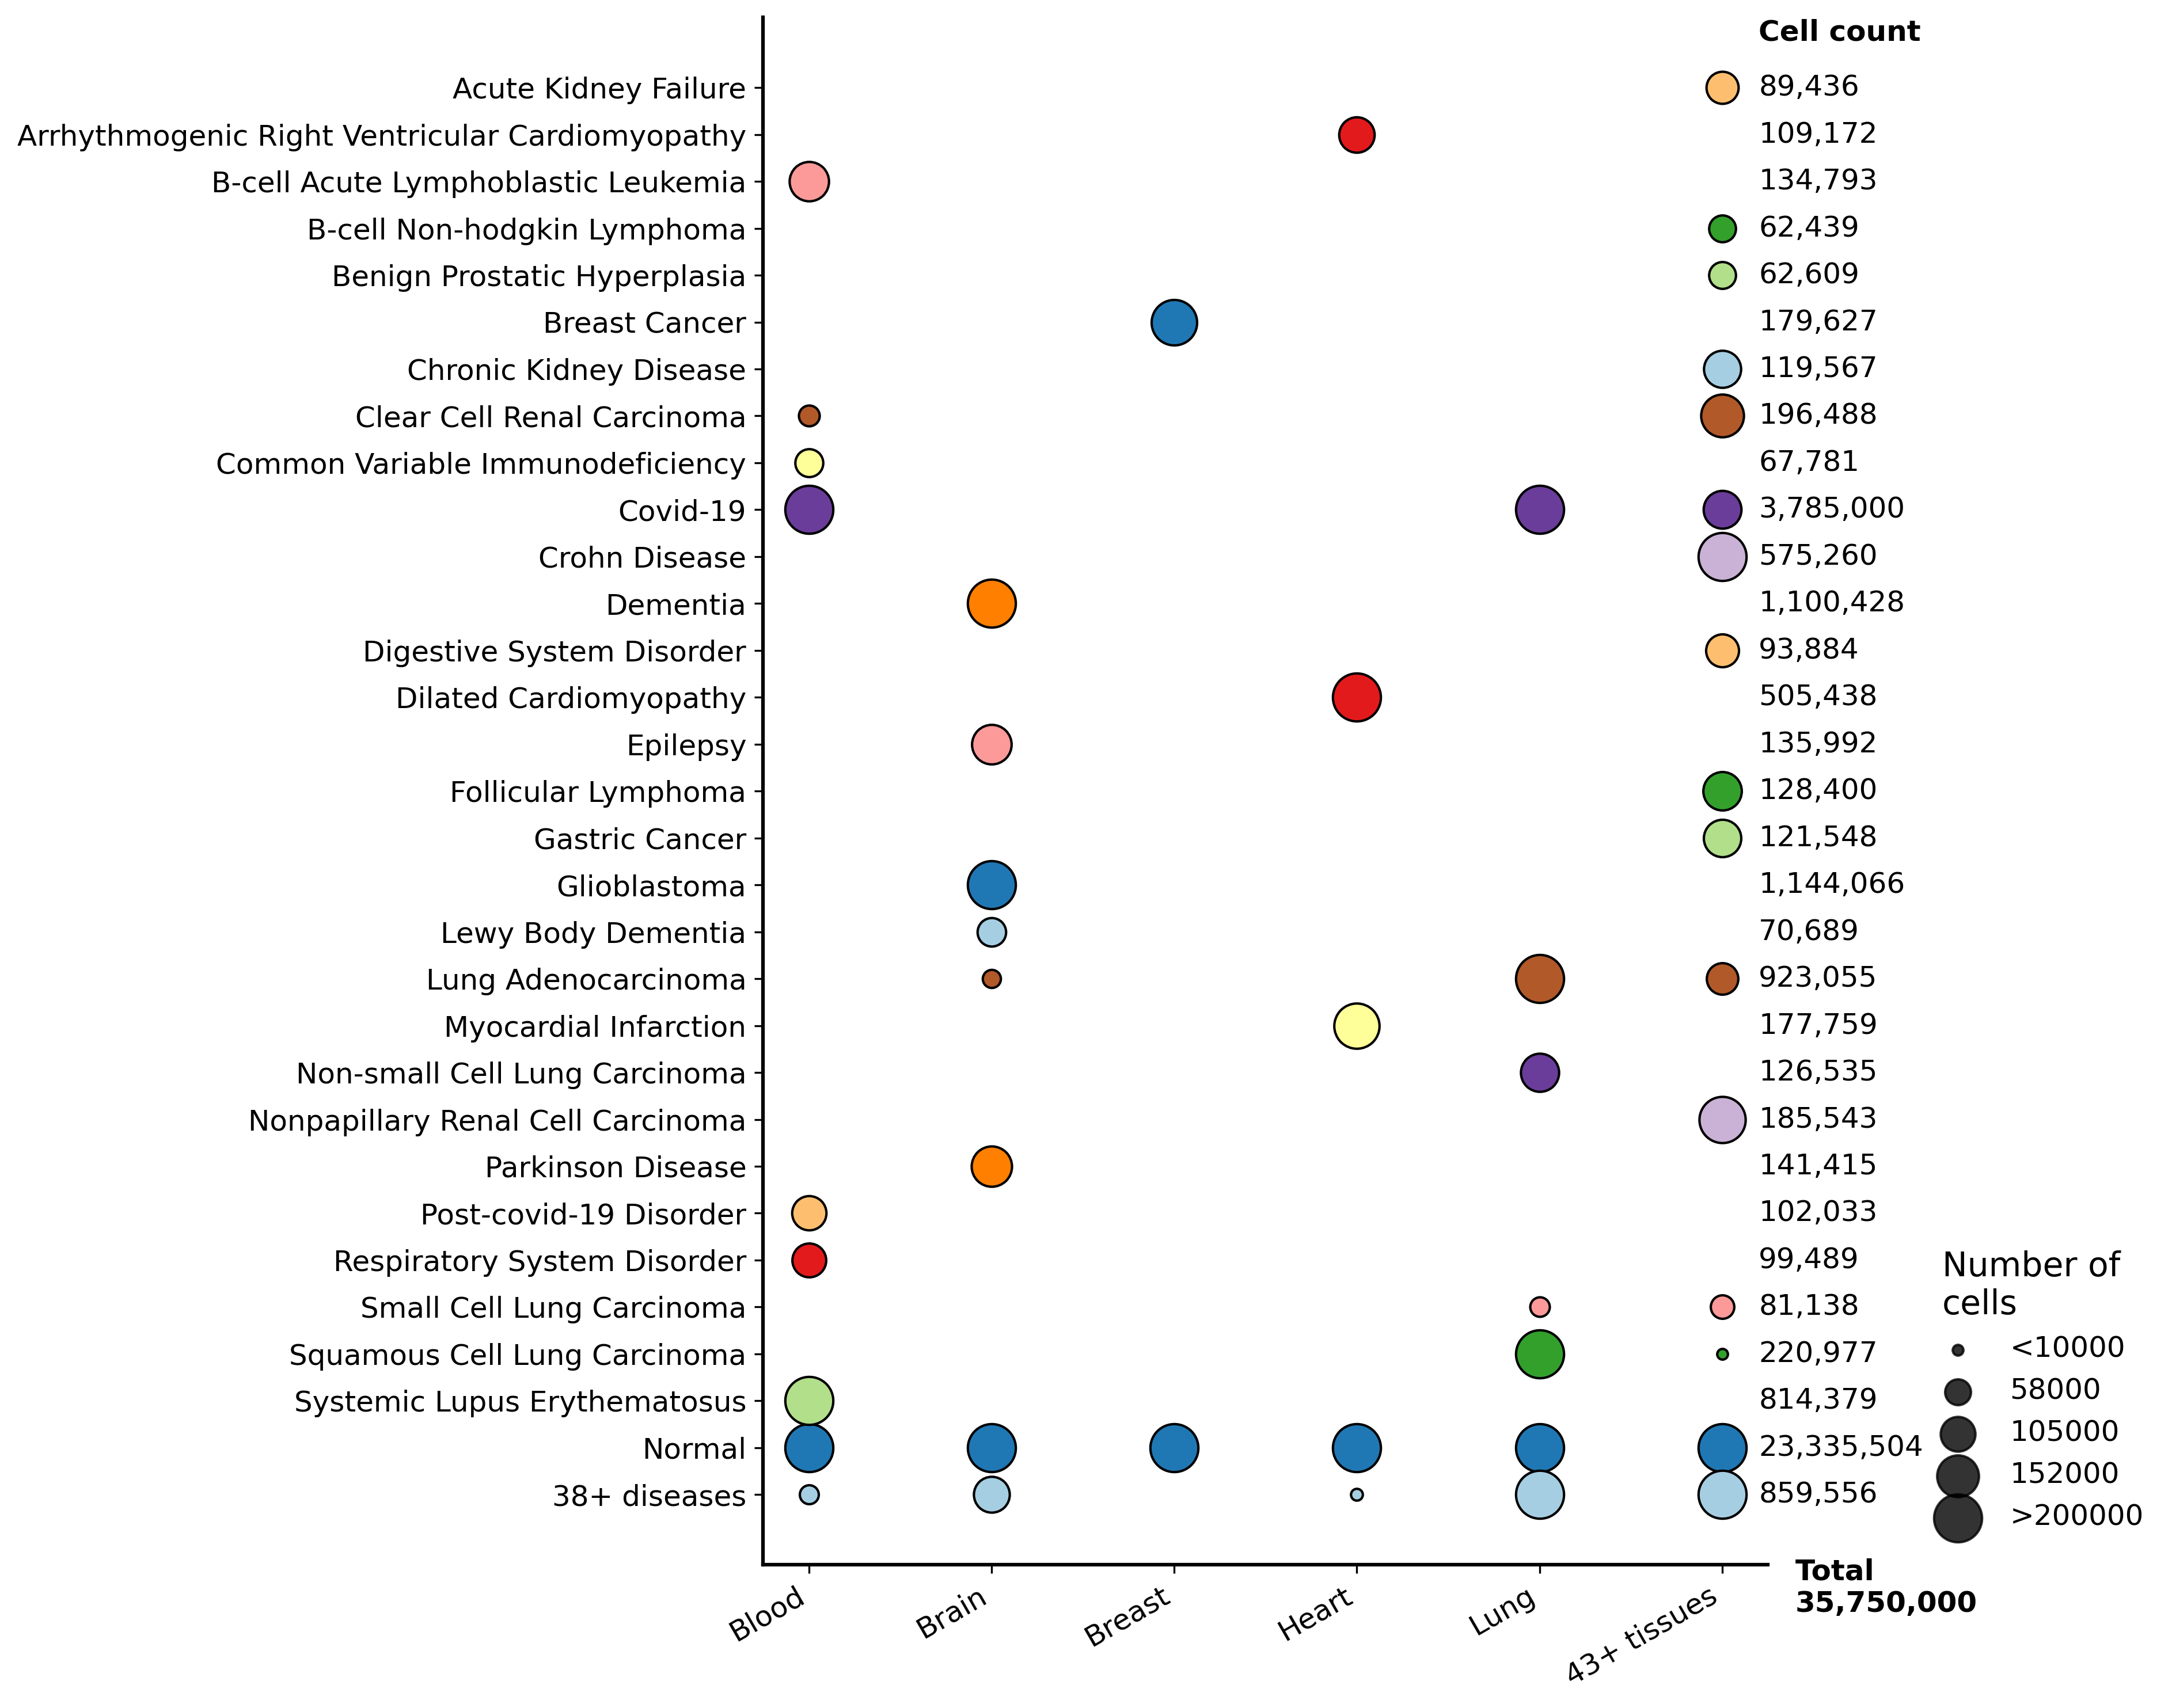

In [4]:
print(column_values, phenotype_values)
SAVE_PATH = '../figures/'
FONTSIZE=12
palette = sns.color_palette("vlag", len(phenotype_values))
palette = sns.color_palette("cubehelix", len(phenotype_values))
palette = sns.color_palette("Paired", len(phenotype_values))
color_map = dict(zip(phenotype_values, palette))
fig, ax = plt.subplots(figsize=(15,10), dpi=300)

size_min, size_max = counts['count'].quantile(0.2), counts['count'].quantile(0.8)
size_min, size_max = int(1e4), int(2e5)
divider = 5e2

for _, row in counts.iterrows():
    ax.scatter(column_values.index(row[column]), phenotype_values.index(row[phenotype]),
               s=max(min(row["count"], size_max), size_min)/divider, c=[color_map[row[phenotype]]], alpha=1, linewidth=1, edgecolors='k')

legend_sizes = np.linspace(size_min, size_max, 5, dtype=int)
legend_sizes = np.round(legend_sizes, -3).astype(int)
for idx, c in enumerate(legend_sizes):
    add = ""
    if idx == 0: add = "<"
    if idx == len(legend_sizes)-1: add = ">"
    ax.scatter([],[],s=c/divider, c="k", alpha=0.8, label=add+str(c))

ax.set_yticks(range(len(phenotype_values)))
y_ticklabels = [f'{n_not_included_rows}+ diseases'] + phenotype_values[1:] if phenotype_values and phenotype_values[0]=='Other' else phenotype_values
ax.set_yticklabels(y_ticklabels)

for i, value in enumerate(phenotype_values):
    total_count = counts.loc[counts[phenotype] == value, "count"].sum()
    ax.text(len(column_values)-1 +0.2, i, f"{total_count:,}", va="center", ha="left", fontsize=FONTSIZE)

ax.set_xticks(range(len(column_values)))
x_ticklabels = column_values[:-1] + [f'{n_not_included_cols}+ tissues'] if column_values and column_values[-1]=='Other' else column_values
ax.set_xticklabels(x_ticklabels, rotation=30, ha='right')

ax.tick_params(labelsize=FONTSIZE)
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.text(x=len(column_values)-1 + 0.2, y=len(phenotype_values), s="Cell count", fontweight="bold", fontsize=FONTSIZE)
ax.text(x=len(column_values)-1 + 0.4, y=-2.5, s=f"Total \n{counts['count'].sum():,}", fontweight="bold", fontsize=FONTSIZE)
ax.legend(title="Number of \ncells", bbox_to_anchor=(1.4,.22), frameon=False, fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'figure1_cellxgene_overview.svg', dpi=300, transparent=True)
plt.show()